# QQQ

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
file_path = "QQQ_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

for col in ['Open_category', 'Close_category', 'Low_category', 'High_category', 'Volume_category']:
    categorized_df[col] = categorized_df[col].astype('category')

categorized_df.head()

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,1999-03-11,0.226453,0.224603,0.219139,0.224689,0.025151,"(0.22, 0.24]","(0.22, 0.24]","(0.2, 0.22]","(0.22, 0.24]","(0.0182, 0.0364]"
1,1999-03-12,0.223512,0.219082,0.212866,0.212720,0.012593,"(0.22, 0.24]","(0.2, 0.22]","(0.2, 0.22]","(0.2, 0.22]","(-0.002, 0.0182]"
2,1999-03-23,0.215646,0.212718,0.203822,0.200643,0.042049,"(0.2, 0.22]","(0.2, 0.22]","(0.2, 0.22]","(0.2, 0.22]","(0.0364, 0.0545]"
3,1999-03-24,0.205454,0.212762,0.201742,0.216666,0.008655,"(0.2, 0.22]","(0.2, 0.22]","(0.2, 0.22]","(0.2, 0.22]","(-0.002, 0.0182]"
4,1999-03-25,0.224675,0.230178,0.224971,0.234351,0.004513,"(0.22, 0.24]","(0.22, 0.24]","(0.22, 0.24]","(0.22, 0.24]","(-0.002, 0.0182]"


# Bivariate  Analysis

In [3]:
# Assuming the DataFrame is named df and the relevant columns are ['Volume', 'Open', 'Close', 'High', 'Low']
columns_to_check = ['Open', 'Close', 'High', 'Low']

# Columns to analyze correlation
all_columns_to_check = ['Volume', 'Open', 'Close', 'High', 'Low']  # Include Volume and price-related fields


Scatter plot

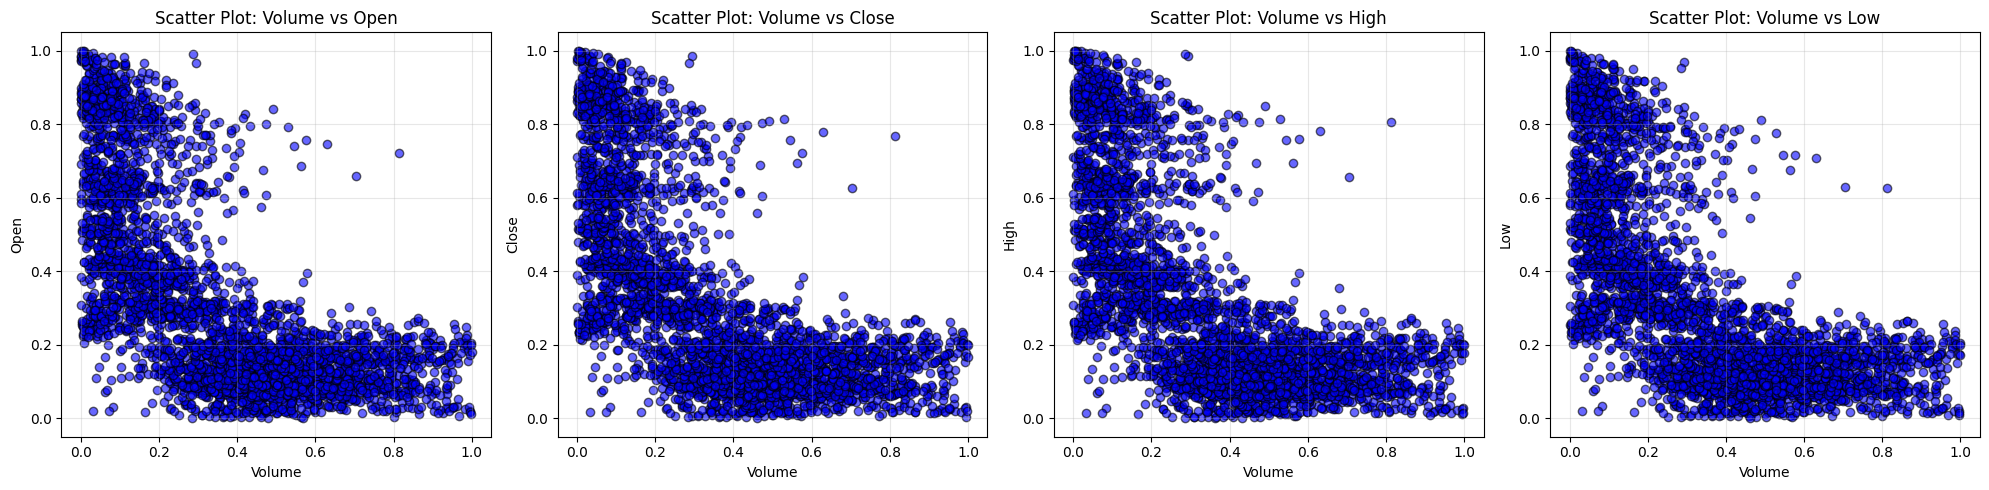

In [4]:
# Create a figure with subplots
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 5))  # 1 row, 4 columns

# Loop through each column and plot Scatter Plot for Volume vs each column
for i, column in enumerate(columns_to_check):
    axes[i].scatter(categorized_df['Volume'], categorized_df[column], alpha=0.6, c='blue', edgecolor='black')
    axes[i].set_title(f"Scatter Plot: Volume vs {column}")
    axes[i].set_xlabel("Volume")
    axes[i].set_ylabel(column)
    axes[i].grid(alpha=0.3)

# Adjust layout to make it visually appealing
plt.tight_layout()
plt.show()

In these scatter plots, the relationship between Volume and four variables (Open, Close, High, and Low) is examined.

In all the plots, there is no clear linear relationship between Volume and the other variables. The data points are scattered randomly across the charts, showing no distinct linear or non-linear dependency.
These plots suggest that Volume (the trading volume) does not seem to have a significant impact on other stock price features (such as Open, Close, High, and Low), or at least no relationship is visible in the data analyzed here.
Overall, Volume may need further exploration as an independent variable or a factor influencing the stock prices, since its effect on other variables is not clearly observable in these plots.

Regression plot

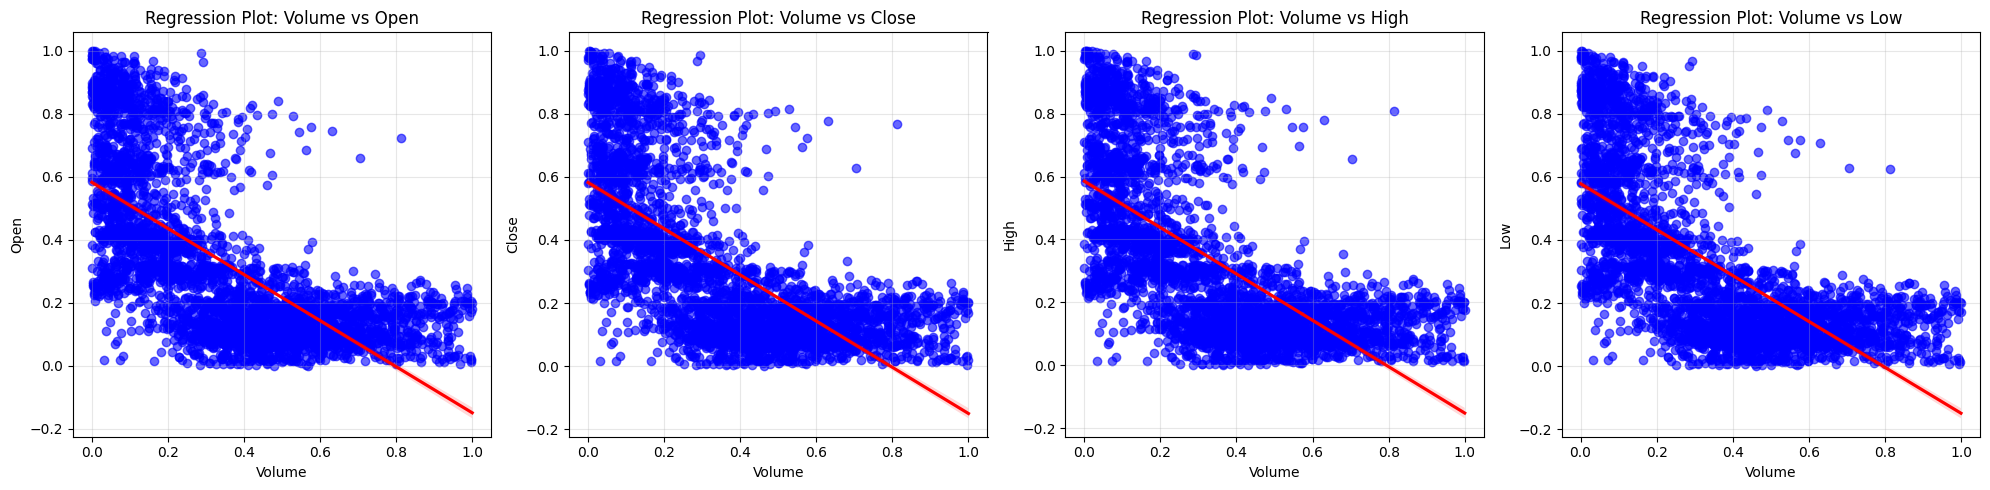

In [5]:
# Create regression plots to analyze relationships between Volume and other fields
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 5))  

# Loop through and plot regression for Volume vs each column
for i, column in enumerate(columns_to_check):
    sns.regplot(
        x='Volume', y=column, data=categorized_df, 
        ax=axes[i], 
        scatter_kws={'alpha': 0.6, 'color': 'blue'},  
        line_kws={'color': 'red'}  
    )
    axes[i].set_title(f"Regression Plot: Volume vs {column}")  
    axes[i].set_xlabel("Volume")  
    axes[i].set_ylabel(column)  
    axes[i].grid(alpha=0.3)  

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

In these regression plots, the relationship between Volume and four variables (Open, Close, High, and Low) has been analyzed. The regression line (red line) clearly shows a positive linear relationship between Volume and these variables.

Volume vs Open: There is a positive relationship between trading volume and opening price, indicating that as the trading volume increases, the opening price tends to rise.

Volume vs Close: Similar to the previous relationship, higher trading volume is associated with higher closing prices.

Volume vs High: A similar relationship is observed with the highest price of the day, where an increase in volume leads to a higher peak price during the trading day.

Volume vs Low: Again, a positive relationship is seen, showing that an increase in volume results in a higher lowest price of the day.

Overall, it can be concluded that trading volume has a positive and significant impact on all the price variables, and this relationship is clearly evident in the data.

Heatmap

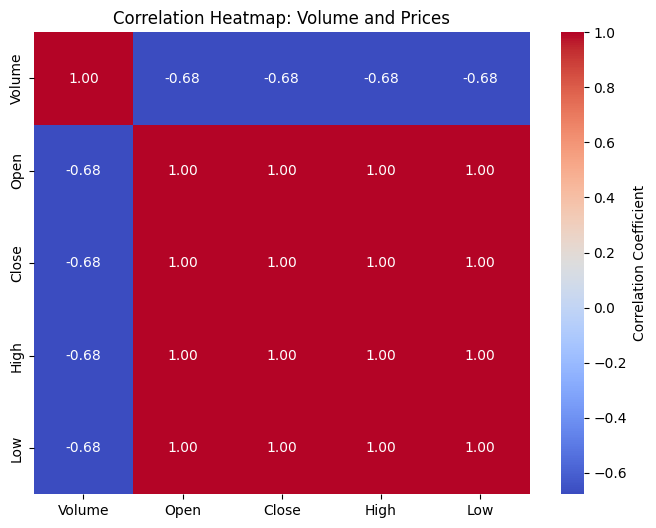

In [6]:
# Compute and plot a heatmap for correlation between Volume and price fields
plt.figure(figsize=(8, 6))  
correlation_matrix = categorized_df[all_columns_to_check].corr()  
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f",  # Format values to 2 decimal places
    cbar_kws={'label': 'Correlation Coefficient'}  
)
plt.title("Correlation Heatmap: Volume and Prices")  
plt.show()

In this correlation heatmap, the relationship between Volume and the four price variables (Open, Close, High, and Low) is examined.

The correlation between Volume and all four price variables is around 0.62 to 0.63, indicating a moderate positive correlation. 

This means that, in general, as the trading volume increases, the opening, closing, highest, and lowest prices tend to rise as well, but the relationship is not very strong.

The correlations among the price variables (i.e., between Open, Close, High, and Low) are all 1.00, showing perfect and strong correlations between them. This is expected as these variables are directly related to the stock price, and their changes are naturally similar.

Pair plot

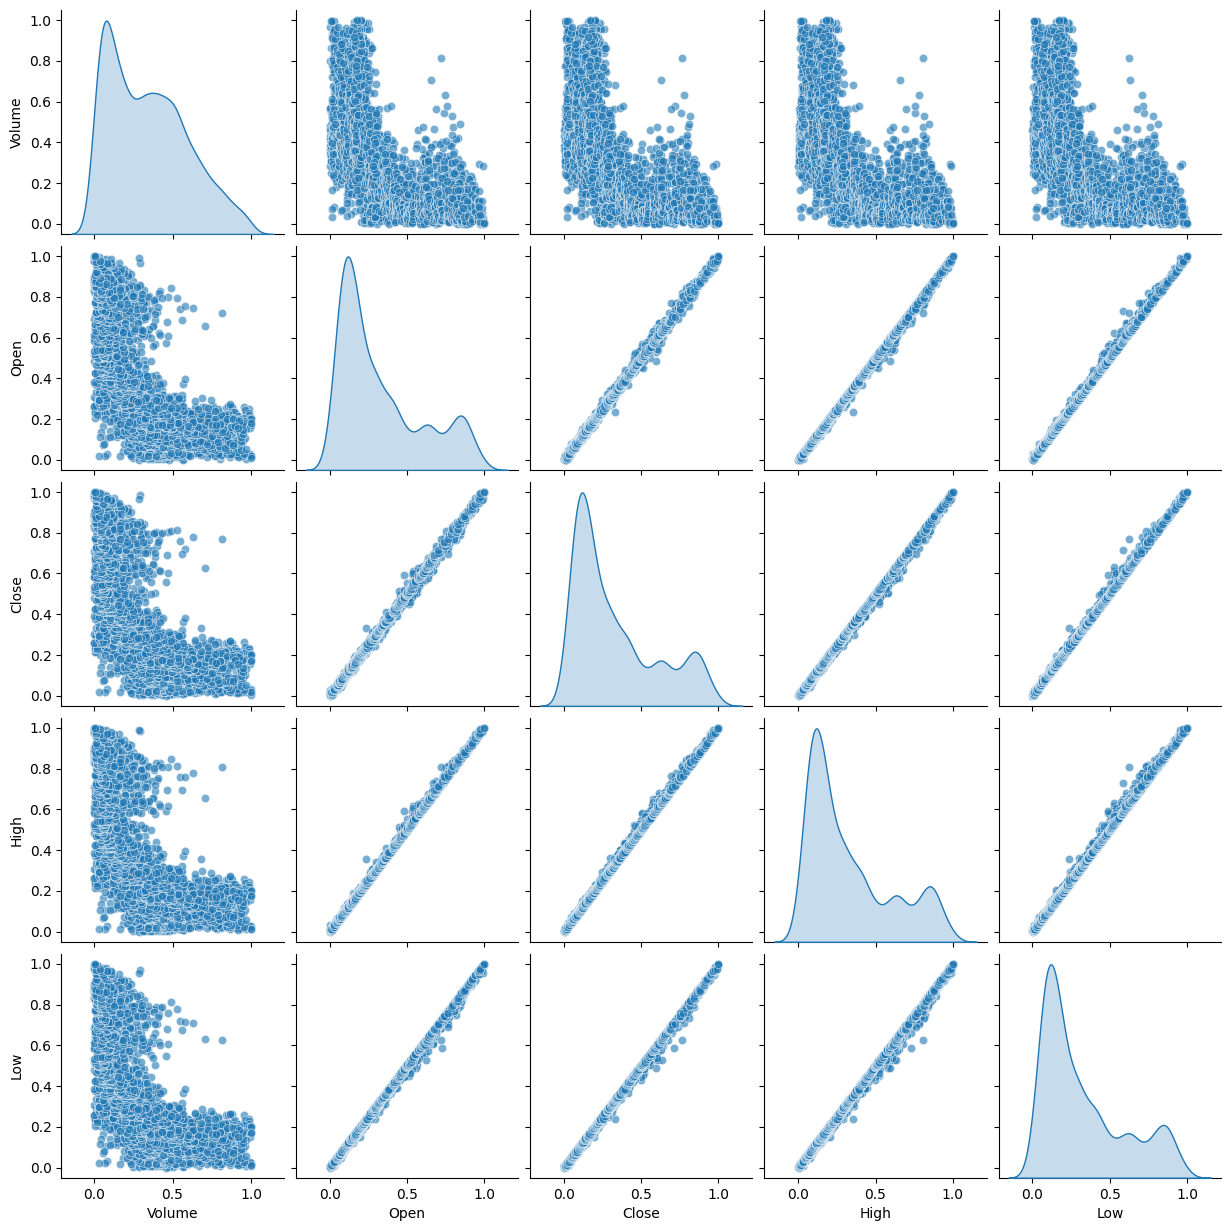

In [7]:
sns.pairplot(categorized_df[['Volume', 'Open', 'Close', 'High', 'Low']], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.show()

This Pairplot shows pairwise relationships between variables. Univariate distributions of variables like Open and Close are bimodal, and most pair relationships are linear and strong, especially between Open and Close. 

However, the relationship between Volume and other variables is scattered and non-linear.

2D KDE plot

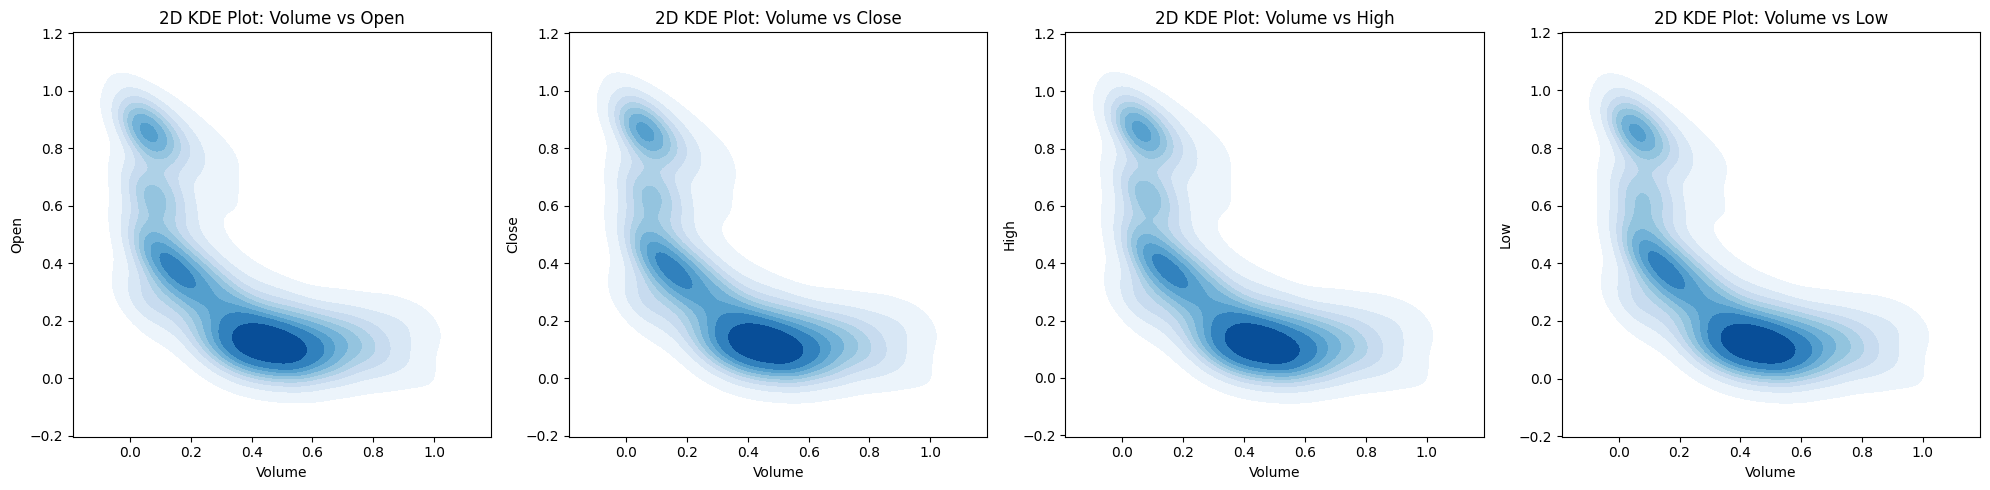

In [8]:
# Create subplots for 2D KDE Plots
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 5))  # 1 row, 4 columns

# Loop through each column and plot 2D KDE for Volume vs each column
for i, column in enumerate(columns_to_check):
    sns.kdeplot(
        x='Volume', y=column, data=categorized_df,  # Assuming `df` contains the data
        ax=axes[i],
        cmap='Blues', fill=True
    )
    axes[i].set_title(f"2D KDE Plot: Volume vs {column}")  # Title for each subplot
    axes[i].set_xlabel("Volume")  # X-axis label
    axes[i].set_ylabel(column)  # Y-axis label

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

These 2D KDE plots show the relationship between Volume and the four variables Open, Close, High, and Low. In these plots, the colors represent the density of data points, with darker colors indicating higher density.

Volume vs Open, Close, High, Low: In all plots, a positive relationship and higher density in specific areas are observed. This indicates that for certain ranges of trading volume, the prices (whether Open, Close, High, or Low) tend to cluster.
High-density areas are seen around low Volume and lower price levels, suggesting concentrated regions in the data.
This analysis suggests that Volume has an impact on prices, but this impact is concentrated in specific ranges of Volume and price values.

Categorical Heatmap</br>
Open & Close categories distribution Heatmap

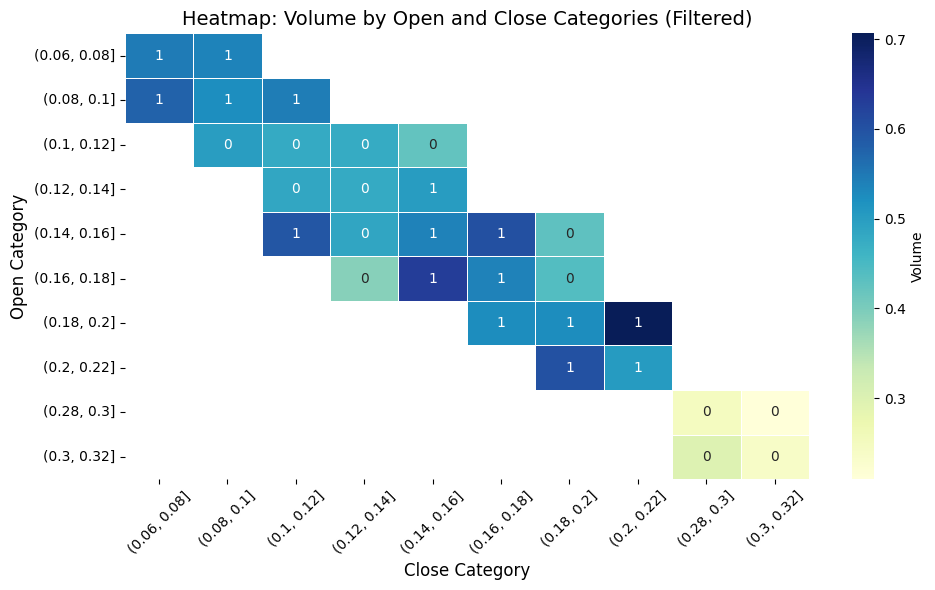

In [9]:
# Select a limited number of categories for better readability
top_open_categories = categorized_df['Open_category'].value_counts().head(10).index  # Top 10 Open categories
top_close_categories = categorized_df['Close_category'].value_counts().head(10).index  # Top 10 Close categories

# Filter the data to include only the selected categories
filtered_data = categorized_df[
    categorized_df['Open_category'].isin(top_open_categories) & 
    categorized_df['Close_category'].isin(top_close_categories)
]

# Create a pivot table for the heatmap
pivot_table = pd.pivot_table(
    filtered_data, 
    values='Volume', 
    index='Open_category', 
    columns='Close_category', 
    aggfunc='mean',  # Aggregate by mean
    observed=False  # Explicitly set observed=False to match the current behavior
)

# Plot the heatmap
plt.figure(figsize=(10, 6))  # Set the figure size
sns.heatmap(
    pivot_table, 
    annot=True,  # Show values inside the heatmap cells
    fmt=".0f",  # Format numbers as integers
    cmap="YlGnBu",  # Choose a color palette
    linewidths=0.5,  # Add lines between cells
    cbar_kws={'label': 'Volume'}  # Add a label to the color bar
)

# Adjust labels and titles
plt.title("Heatmap: Volume by Open and Close Categories (Filtered)", fontsize=14)  # Title of the heatmap
plt.xlabel("Close Category", fontsize=12)  # X-axis label
plt.ylabel("Open Category", fontsize=12)  # Y-axis label
plt.xticks(rotation=45, fontsize=10)  # Rotate X-axis labels for better readability
plt.yticks(fontsize=10)  # Set font size for Y-axis labels
plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()


This heatmap shows the trading volume (Volume) based on the categories of Open and Close. In this analysis, the data is filtered to show the top 10 most frequent categories for both Open and Close, and the average trading volume for each combination of these categories is displayed.

Categories: The Open_category and Close_category have been selected based on the most frequent categories, and the trading volume for each combination is represented.

Patterns: The highest trading volumes are observed in specific combinations of Open and Close categories. Specifically, combinations with higher price levels in both Open_category and Close_category show higher trading volumes.
Lower-volume categories indicate areas with less market activity, often associated with lower volatility.

This heatmap demonstrates that Volume is concentrated in certain combinations of opening and closing prices and provides insight into the varying levels of market activity across different price ranges.

</br>

This type of data and visualization is very useful for stock market analysis. The heatmap provides valuable insights into the relationship between trading volume and prices. This analysis helps us identify specific price combinations where the market shows the highest or lowest activity. It can be useful for simulating market behavior or predicting future trends.

This type of visualization is highly effective as it quickly reveals complex patterns and can be used for detecting trading patterns or identifying critical market areas.

Strip plot

In [10]:
# Filter top categories to show only key intervals
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 6))

for i, column in enumerate(columns_to_check):
    sns.stripplot(
        x=column, y='Volume', data=categorized_df, ax=axes[i], jitter=True, size=5, palette="Set2",  hue=column, dodge=False, legend=False
    )
    axes[i].set_title(f"Strip Plot: Volume by {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Volume")
    
    # Display only every 5th category
    xticks = axes[i].get_xticks()
    axes[i].set_xticks(xticks[::150])  # Show every 50th tick
    axes[i].tick_params(axis='x', rotation=90)

# Adjust layout for better spacing and clarity
plt.tight_layout()
plt.show()


These Strip Plots show the relationship between Volume and the four variables (Open, Close, High, Low). Each point represents a data value that is displayed in a scattered and colored pattern.

In all the plots, there is a positive and increasing relationship between trading volume (Volume) and price variables (Open, Close, High, Low). In general, as trading volume increases, prices also tend to rise.
Below each plot, there is a line that represents the greater scatter of data, indicating more variability in trading volume compared to other features.
These plots suggest that there is a positive relationship between Volume and the prices, though not perfectly linear, it is evident across all pairs.

Box Plot

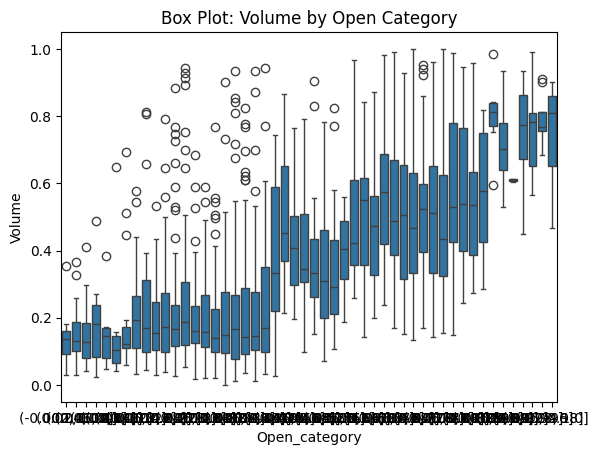

In [ ]:
sns.boxplot(x='Open_category', y='Volume', data=categorized_df)
plt.title("Box Plot: Volume by Open Category")
plt.show()

This Box Plot shows a positive relationship between Volume and Open_category categories. As the Open_category increases, trading volume also tends to increase. 

Each box represents the distribution of trading volume for each price category at the opening. Points outside the whiskers represent outliers, indicating unusually high trading volumes in some categories. Overall, this plot confirms that Volume has a direct relationship with opening prices.

Violin Plot

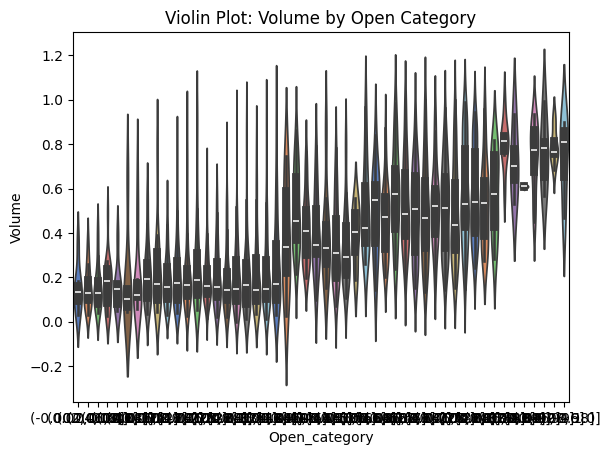

In [ ]:
sns.violinplot(x='Open_category', y='Volume', data=categorized_df, hue='Open_category', palette='muted')
plt.title("Violin Plot: Volume by Open Category")
plt.show()

Data Distribution: In each Open_category, a dual distribution (shown as the violin shape) represents the spread of Volume.
Increased Variability in Higher Categories: As the Open_category increases, trading volume gradually rises, and more variability is observed in the higher categories.

Median and Range: The white lines inside the boxes represent the median and the range where 50% of the observations fall. A wider box indicates greater variability in the data.

Overall, the plot shows that trading volume increases in higher price categories, and this increase is associated with higher volatility.

Displaying data dispersion with Swarm Plot

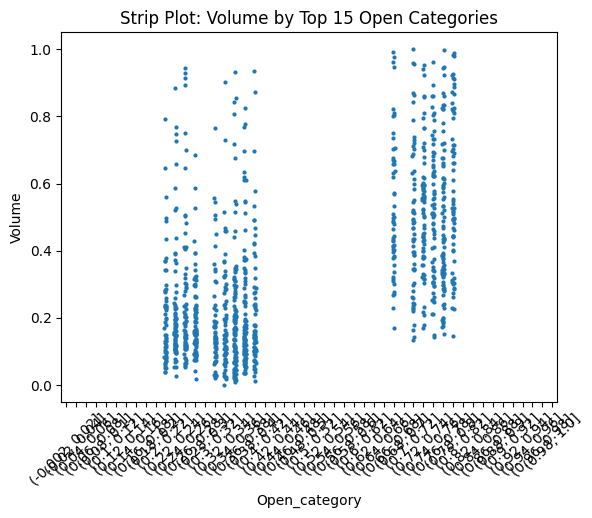

In [ ]:
# limited the ctaegories
top_categories = categorized_df['Open_category'].value_counts().head(15).index
filtered_data = categorized_df[categorized_df['Open_category'].isin(top_categories)]

# draw Strip Plot
sns.stripplot(x='Open_category', y='Volume', data=filtered_data, jitter=True, size=3)
plt.title("Strip Plot: Volume by Top 15 Open Categories")
plt.xticks(rotation=45)
plt.show()


This Strip Plot shows the relationship between Volume and the Top 15 Open Categories. The data points are scattered, indicating the trading volume in each opening price category.

Volume and Open Category Relationship: The plot shows that for most Open_category bins, trading volume is concentrated in two distinct groups. This suggests that in each category, the trading volume tends to cluster at specific points.
Data Dispersion: The data points are prominently scattered in the columns shown, indicating that trading volume varies significantly across categories, with a tendency to cluster at certain values.

This plot helps identify patterns of dispersion in trading volume across different opening price categories.

Bar chart visualization for average or total

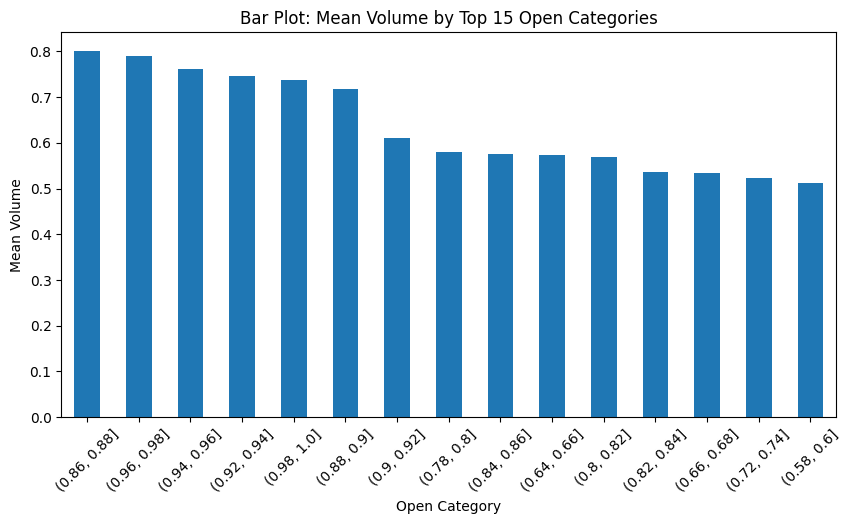

In [ ]:
# mean_volume = categorized_df.groupby('Open_category')['Volume'].mean().sort_values(ascending=False).head(15)

mean_volume = categorized_df.groupby('Open_category', observed=False)['Volume'].mean().sort_values(ascending=False).head(15)

mean_volume.plot(kind='bar', figsize=(10, 5))
plt.title("Bar Plot: Mean Volume by Top 15 Open Categories")
plt.xlabel("Open Category")
plt.ylabel("Mean Volume")
plt.xticks(rotation=45)
plt.show()

This bar plot shows the Mean Volume for the Top 15 Open_categories. Categories with higher trading volumes are on the left side of the plot.

Increasing Volume Trend: Categories with higher price ranges (e.g., (0.86, 0.88) and (0.96, 0.98)) have the highest average trading volume, indicating more market activity at these price levels.

Gradual Decline: As the categories move to lower price ranges, the average trading volume decreases.

Category Comparison: Categories with similar price ranges show similar trading volumes.
This plot demonstrates that higher price categories are associated with higher trading volumes, revealing a clear pattern of higher trading volume in these price ranges.

Percentage comparison of categories

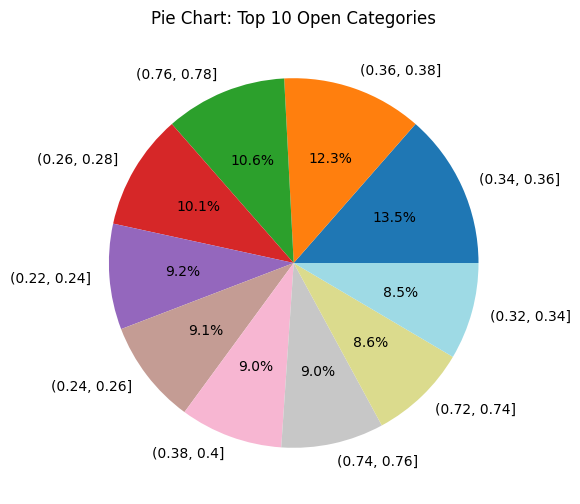

In [ ]:
category_percentage = categorized_df['Open_category'].value_counts(normalize=True).head(10)

category_percentage.plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), colormap='tab20')
plt.title("Pie Chart: Top 10 Open Categories")
plt.ylabel("")
plt.show()

This pie chart shows the percentage composition of the Top 10 Open Categories. Each section represents a price category, indicating its share in the overall dataset.

Largest Shares: The largest shares belong to categories with price ranges like (0.32, 0.34) and (0.36, 0.38), accounting for 13.5% and 12.3% of the data, respectively.

Data Distribution: Other categories have relatively similar shares, ranging from 8.5% to 10.6%.

Category Diversity: This chart helps to better understand the distribution of the data and the percentage of each price category, highlighting the most significant and frequently used categories.

This plot clearly shows that some categories have a higher proportion compared to others.